### Autors

Ziyi Hong - *2694933*

Danylo Tulainov - *5070969*

# Laborarbeit - Teil 2

## Ausgangssituation

Sie arbeiten im Data-Science-Team eines Unternehmens mit internem IT-Support.

Die Support-Leitung möchte eingehende Tickets automatisch danach einstufen, ob sie niedrige oder hohe Priorität haben. Ziel ist es, kritische Tickets schneller zu erkennen und zeitnah zu bearbeiten.

Die Fachabteilung stellt dabei zwei Anforderungen:

1. Das Verfahren soll einfach und nachvollziehbar sein.
2. Es soll möglich sein, für beide Klassen (niedrige Priorität/hohe Priorität) die wichtigsten Signalwörter anzugeben, also Wörter, die eher für hohe bzw. niedrige Priorität sprechen.

Außerdem steht nur ein relativ kleiner Datensatz zur Verfügung. Die Support-Leitung bevorzugt daher ein Verfahren, das auch bei begrenzter Datenmenge stabil einsetzbar ist.

## Datensatz

Sie erhalten den Datensatz `support_tickets_synthetisch_200.csv`.
Die Datei enthält die folgenden Spalten:

- `ticket_id`: eindeutige Ticket-ID
- `subject`: Betreff des Tickets
- `message`: eigentliche Ticketbeschreibung
- `priority`: Zielvariable mit den Klassen `hoch` und `niedrig`

## Aufgabe

**Ihre Aufgabe ist es auf Basis dieser Anforderungen eine Lösung für das Support-Team zu entwickeln.**

## Hinweise

Die Aufgabenstellung ist bewusst offen gehalten. Berücksichtigen Sie bei der Bearbeitung der Aufgabe die folgenden Hinweise:
* Dokumentieren Sie Ihr Vorgehen strukturiert und nachvollziehbar.
* Begründen Sie Ihre Vorgehensweise und Entscheidungen.
* Interpretieren Sie Ergebnisse.
* Erstellen Sie, wo möglich und sinnvoll, Plots.
* **Nutzen Sie nur Methoden, Konzepte und Begründungen, die in der Vorlesung behandelt wurden. Falls dies nicht möglich ist, begründen Sie warum.**
* Identifizieren Sie Schwachstellen/Limitationen Ihrer Arbeit und erläutern Sie diese auf Basis der Vorlesungsinhalte.

Berücksichtigen Sie die folgenden Hinweise für die Abgabe:
* Arbeiten Sie in 2er-Gruppen und geben Sie je Gruppe ein Notebook ab.
* Nennen Sie im abgegebenen Notebook die Gruppenmitglieder.
* **Für die Verwendung von KI berücksichtigen Sie die Hinweise von Herrn Prof. Hänisch.**
* Die erste Abgabe muss am Dienstag, den 17.03., zwischen 15:30 und 16:15 Uhr per Moodle erfolgen.
* Die endgültige Abgabe muss bis Dienstag, den 24.03., um 23:59 Uhr per Moodle erfolgen.
* Gewertet wird die endgültige Abgabe. Wenn Sie zwischen erster und endgültiger Abgabe Änderungen vornehmen, müssen Sie diese begründen.

## Business Understanding

The first stage of **CRISP-DM**.

The goal of this task is to automate the classification of internal IT support tickets into high and low priority categories. The support team requires a simple, transparent model that works stably on a small dataset and can extract *signal words* that influence the classification decisions.

## Data understanding and Data Preparation

According to **CRISP-DM** the next step is *Data Understanding*. This is combined with *Data Preparation* in this task, since the second one consists only of one step.

At this stage the following steps are taken:
- Load of dataset
- Combine text features into one
- Store the target feature to `y` and training features to `X`
- Feature engineering:
    - Find the unique categories per target feature
    - Outline top features
- Train-test-split

#### Import packages

In [50]:
import pandas as pd
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

In [51]:
# Load the dataset
df = pd.read_csv('support-dataset.csv')

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ticket_id  200 non-null    str  
 1   subject    200 non-null    str  
 2   message    200 non-null    str  
 3   priority   200 non-null    str  
dtypes: str(4)
memory usage: 6.4 KB


In [52]:
df.head()

,ticket_id,subject,message,priority
0,TKT-0039,Sicherheitsvorfall in Dateiserver,Es besteht der Verdacht auf einen Sicherheitsv...,niedrig
1,TKT-0134,Später umsetzen: Export nach Excel in SAP,Die Anpassung Export nach Excel in SAP wäre hi...,hoch
2,TKT-0070,Verdacht auf Datenverlust in E-Mail,In E-Mail fehlen seit 45 Minuten Datensätze. E...,hoch
3,TKT-0192,Wunsch: Dark Mode in Citrix,"Für Produktion besteht der Wunsch, in Citrix D...",niedrig
4,TKT-0018,Produktionsstillstand wegen Problemen mit Intr...,Durch Probleme mit Intranet besteht Produktion...,hoch


#### Define target and training variables

It was decided to combine features `subject` and `message` to maximize context. They are stored in `X`.

In [53]:
y = df['priority']

df['text'] = df['subject'] + ' ' + df['message']
X = df['text']

X.shape

(200,)

In [54]:
y.shape

(200,)

#### Check the unique values in `y`

In [64]:
y.value_counts()

priority
niedrig    100
hoch       100
Name: count, dtype: int64

Since there are only 2 unique values - which are 'hoch' and 'niedrig' it was decided that the **Naive Bayes** approach is the most suitable for this task. The dataset is small - only 200 entries.

**Naive Bayes** directly calculates the conditional probabilities of individual words, that satisfies the transparency and word extraction requirements. Moreover, it remains stable with limited training data.

#### Train-test-split

In [56]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(X_train.shape)
print(X_test.shape)
print(y_test.shape)
print(y_train.shape)

(160,)
(40,)
(40,)
(160,)


## Modeling

The next stage is *Modeling*. Here following logic is done:
- Model evaluation
- Model training

#### Model training

The first training of the model is made using a `Pipeline` to streamline the execution. Text features are transformed directly inside the pipeline.

In [57]:
nb_model = Pipeline([
    ("vec", CountVectorizer(lowercase=True)),
    ("clf", MultinomialNB(alpha=1.0))
])

nb_model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('vec', ...), ('clf', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"input input: {'filename', 'file', 'content'}, default='content'- If `'filename'`, the sequence passed as an argument to fit is expected to be a list of filenames that need reading to fetch the raw content to analyze.- If `'file'`, the sequence items must have a 'read' method (file-like object) that is called to fetch the bytes in memory.- If `'content'`, the input is expected to be a sequence of items that can be of type string or byte.",'content'
,"encoding encoding: str, default='utf-8'If bytes or files are given to analyze, this encoding is used todecode.",'utf-8'
,"decode_error decode_error: {'strict', 'ignore', 'replace'}, default='strict'Instruction on what to do if a byte sequence is given to analyze thatcontains characters not of the given `encoding`. By default, it is'strict', meaning that a UnicodeDecodeError will be raised. Othervalues are 'ignore' and 'replace'.",'strict'
,"strip_accents strip_accents: {'ascii', 'unicode'} or callable, default=NoneRemove accents and perform other character normalizationduring the preprocessing step.'ascii' is a fast method that only works on characters that havea direct ASCII mapping.'unicode' is a slightly slower method that works on any characters.None (default) means no character normalization is performed.Both 'ascii' and 'unicode' use NFKD normalization from:func:`unicodedata.normalize`.",None
,"lowercase lowercase: bool, default=TrueConvert all characters to lowercase before tokenizing.",True
,"preprocessor preprocessor: callable, default=NoneOverride the preprocessing (strip_accents and lowercase) stage whilepreserving the tokenizing and n-grams generation steps.Only applies if ``analyzer`` is not callable.",None
,"tokenizer tokenizer: callable, default=NoneOverride the string tokenization step while preserving thepreprocessing and n-grams generation steps.Only applies if ``analyzer == 'word'``.",None


## Evaluation

The last stage of **CRISP-DM** is *Evaluation*. At this stage:
- the model's predictions are calculated
- the top features are found

In [58]:
y_pred = nb_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))

Accuracy: 1.0


To ensure that `accuracy_score`'s result was correct, the `classification_report` is used.

`classification_report` provides detailed information of the model's performance for each class, which are in this task 'hoch' and 'niedrig'.

In [59]:
print("Classification report's results:")
print(classification_report(y_test, y_pred))

Classification report's results:
              precision    recall  f1-score   support

        hoch       1.00      1.00      1.00        20
     niedrig       1.00      1.00      1.00        20

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40



#### Find the top features

This step is essential to check whether each feature belongs to 'hoch' or 'niedrig' priority classes.

This shows exactly which words trigger which class makes the model transparent, which helps with interpretation of results.

In [60]:
vectorizer = nb_model.named_steps['vec']
clf = nb_model.named_steps['clf']

feature_names = vectorizer.get_feature_names_out()
class_labels = clf.classes_.tolist()
hoch = class_labels.index('hoch')
niedrig = class_labels.index('niedrig')

#### Extract log probabilities

In [61]:
log_prob_hoch = clf.feature_log_prob_[hoch]
log_prob_niedrig = clf.feature_log_prob_[niedrig]

# here is calculated importance score
importance_score = log_prob_hoch - log_prob_niedrig

In [62]:
signal_words_df = pd.DataFrame({
    'word': feature_names,
    'score': importance_score
})

top_words_hoch = signal_words_df.sort_values(by='score', ascending=False).head(10)
top_words_niedrig = signal_words_df.sort_values(by='score', ascending=True).head(10)

print("\nTop Signal Words for Priority: HOCH")
display(top_words_hoch)
print("\nTop Signal Words for Priority: NIEDRIG")
display(top_words_niedrig)


Top Signal Words for Priority: HOCH


,word,score
159,mehr,3.541289
211,seit,3.325066
56,blockiert,3.289975
147,können,3.289975
266,wodurch,3.289975
248,verhindert,3.002293
25,aus,2.953503
7,aktuell,2.953503
172,möglich,2.902210
160,mehrere,2.902210



Top Signal Words for Priority: NIEDRIG


,word,score
61,das,-4.031214
239,um,-3.300326
233,thema,-3.261105
175,nachrangig,-3.220283
183,nutzung,-3.086752
88,empfehlung,-3.086752
277,zur,-3.086752
188,optimierung,-2.986668
181,nur,-2.932601
234,ticket,-2.875443


#### Plot the results

The top signal words are plotted

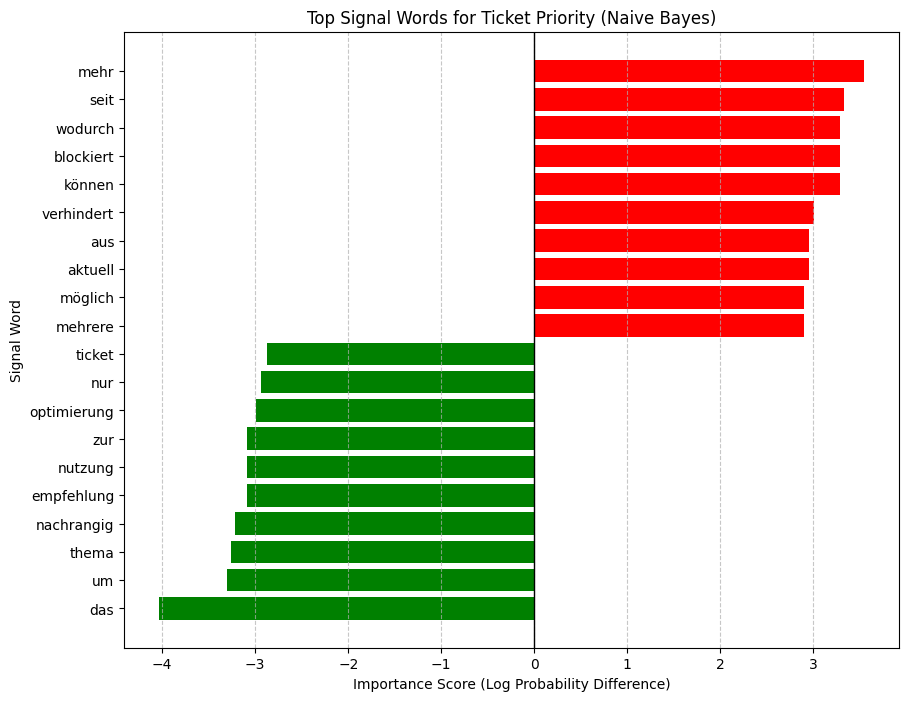

In [63]:
plot_df = pd.concat([top_words_hoch, top_words_niedrig]).sort_values(by='score')

plt.figure(figsize=(10, 8))
colors = ['green' if score < 0 else 'red' for score in plot_df['score']]
plt.barh(plot_df['word'], plot_df['score'], color=colors)
plt.title('Top Signal Words for Ticket Priority (Naive Bayes)')
plt.xlabel('Importance Score (Log Probability Difference)')
plt.ylabel('Signal Word')
plt.axvline(0, color='black', linewidth=1)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Limitation


The *Naive Bayes* approach works perfectly well for this specific task, but it has distinct limitations. Based on the approach itself.

Firstly, the *Naive Bayes* algorithm assumes all features (which are words in this task) are completely independent of one another.

Another limitation lays in `CountVectorizer`. It creates a *Bag of Words*, meaning the model ignores the syntax, grammar and order of words.

Consequently, the model struggles with negations. For instance, if word 'emergency' ('Notfall') is learned as a strong signal for high priority, the phrase 'no emergency' ('kein Notfall') can be misclassified as high priority, because the model processes 'no' ('kein') and 'emergency' ('Notfall') independently.

Another limitation is the **size of the dataset**. *Naive Bayes* is generally robust on small datasets compared to complex algorithms like *Neural Networks*, however the limited vocabulary size means the model might struggle if future tickets contain entirely new terminology or slang what was not present in the training dataset's vocabulary.